# 🏥 CODTECH IT Solutions — Data Analytics Internship
## Task 1: Big Data Analysis
### Project: Hospital Patient Records — Big Data Analysis using Dask

| Field | Details |
|-------|--------|
| **Name** | Kamal Lochan Mishra |
| **Intern ID** | CTIS05S1 |
| **Domain** | Data Analytics |
| **Duration** | 4 Weeks |
| **Mentor** | Neela Santhosh Kumar |
| **Company** | CODTECH IT Solutions Pvt. Ltd. |

---

### 🎯 Objective
Perform **Big Data Analysis** on a large hospital patient dataset (**10,000 records × 31 columns**) using **Dask** for scalable parallel processing. Derive actionable healthcare insights.

### 📌 Analysis Sections
1. Environment Setup & Load Data with Dask
2. Dataset Overview & Quality Check
3. KPI Dashboard
4. Department & Hospital Revenue Analysis
5. Monthly Admissions Trend
6. Payment Mode Analysis
7. Patient Demographics Analysis
8. Treatment & Cost Analysis
9. Correlation Analysis
10. Dask Scalability Demo
11. Key Insights Summary

---
## Section 1 — Environment Setup

In [4]:
# Install if needed:
# !pip install dask pandas matplotlib seaborn pyarrow

In [5]:
import dask.dataframe as dd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('=' * 55)
print('  CODTECH TASK 1 — Hospital Big Data Analysis')
print('=' * 55)

  CODTECH TASK 1 — Hospital Big Data Analysis


---
## Section 2 — Load Data with Dask

In [6]:
# Load with Dask — lazy parallel read
ddf = dd.read_csv('hospital_data.csv', dtype=str)

print(f'Dask Partitions : {ddf.npartitions}')
print(f'Total Columns   : {len(ddf.columns)}')
print(f'Columns         : {list(ddf.columns)}')

Dask Partitions : 1
Total Columns   : 31
Columns         : ['patient_id', 'admission_date', 'discharge_date', 'month', 'quarter', 'year', 'hospital', 'department', 'diagnosis', 'admission_type', 'patient_age', 'patient_gender', 'blood_group', 'state', 'length_of_stay_days', 'bed_type', 'icu_days', 'doctor_visits', 'tests_conducted', 'surgeries', 'medicine_cost', 'doctor_fee', 'lab_cost', 'room_cost', 'total_bill', 'payment_mode', 'insurance_covered', 'out_of_pocket', 'patient_status', 'readmission_flag', 'satisfaction_score']


In [7]:
# Compute to pandas for full analysis
pdf = ddf.compute()

# Type conversions
num_cols = ['patient_age','length_of_stay_days','icu_days','doctor_visits',
            'tests_conducted','surgeries','medicine_cost','doctor_fee',
            'lab_cost','room_cost','total_bill','insurance_covered',
            'out_of_pocket','satisfaction_score','readmission_flag']
for col in num_cols:
    pdf[col] = pd.to_numeric(pdf[col], errors='coerce')
pdf['admission_date'] = pd.to_datetime(pdf['admission_date'], errors='coerce')

print(f'Dataset loaded: {pdf.shape[0]:,} rows x {pdf.shape[1]} columns')
pdf.head(5)

Dataset loaded: 10,000 rows x 31 columns


,patient_id,admission_date,discharge_date,month,quarter,year,hospital,department,diagnosis,admission_type,...,doctor_fee,lab_cost,room_cost,total_bill,payment_mode,insurance_covered,out_of_pocket,patient_status,readmission_flag,satisfaction_score
0,PAT00001,2021-08-17,2021-08-25,Aug,Q3,2021,Kokilaben Mumbai,Cardiology,Arrhythmia,Elective,...,12239.37,8506.43,29776.71,62539.22,Credit,0.0,62539.22,Discharged,1,3.8
1,PAT00002,2021-01-14,2021-01-23,Jan,Q1,2021,Apollo Mumbai,Neurology,Parkinson,Routine,...,14729.77,8136.18,43911.19,107229.99,Corporate,0.0,107229.99,Discharged,0,4.5
2,PAT00003,2023-01-11,2023-01-13,Jan,Q1,2023,Max Chennai,Nephrology,CKD,Emergency,...,7614.23,5678.68,2885.56,48144.85,Government Scheme,0.0,48144.85,Under Treatment,0,3.8
3,PAT00004,2021-12-17,2022-01-01,Dec,Q4,2021,AIIMS Delhi,Gastroenterology,Liver Cirrhosis,Elective,...,1790.68,13714.41,45784.65,81647.4,Government Scheme,0.0,81647.4,Discharged,1,3.2
4,PAT00005,2023-07-29,2023-08-06,Jul,Q3,2023,Kokilaben Mumbai,Neurology,Migraine,Elective,...,1418.77,1822.81,26588.06,34829.66,Corporate,0.0,34829.66,Discharged,1,3.1


---
## Section 3 — Dataset Overview & Quality Check

In [8]:
print('--- Data Types ---')
print(pdf.dtypes)

--- Data Types ---
patient_id                     string
admission_date         datetime64[us]
discharge_date                 string
month                          string
quarter                        string
year                           string
hospital                       string
department                     string
diagnosis                      string
admission_type                 string
patient_age                     Int64
patient_gender                 string
blood_group                    string
state                          string
length_of_stay_days             Int64
bed_type                       string
icu_days                        Int64
doctor_visits                   Int64
tests_conducted                 Int64
surgeries                       Int64
medicine_cost                 Float64
doctor_fee                    Float64
lab_cost                      Float64
room_cost                     Float64
total_bill                    Float64
payment_mode                   

In [9]:
print('--- Statistical Summary ---')
pdf[num_cols].describe().round(2)

--- Statistical Summary ---


,patient_age,length_of_stay_days,icu_days,doctor_visits,tests_conducted,surgeries,medicine_cost,doctor_fee,lab_cost,room_cost,total_bill,insurance_covered,out_of_pocket,satisfaction_score,readmission_flag
count,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
mean,43.28,15.33,0.81,7.91,10.56,1.49,25270.14,10306.86,7596.73,42015.58,85189.31,7609.12,77580.19,3.5,0.26
std,24.48,8.66,1.79,4.34,5.76,1.12,14337.73,5607.42,4289.91,32888.51,36470.86,19622.36,38769.19,0.87,0.44
min,1.0,1.0,0.0,1.0,1.0,0.0,506.1,502.35,200.1,502.38,11706.01,0.0,3060.83,2.0,0.0
25%,22.0,8.0,0.0,4.0,6.0,0.0,12921.69,5552.35,3891.8,15250.07,58246.34,0.0,49653.19,2.7,0.0
50%,44.0,15.0,0.0,8.0,11.0,1.0,25060.61,10221.3,7569.4,33423.95,78732.64,0.0,72411.73,3.5,0.0
75%,64.0,23.0,0.0,12.0,16.0,2.0,37905.21,15235.68,11345.92,62241.68,107553.68,0.0,101258.87,4.2,1.0
max,85.0,30.0,7.0,15.0,20.0,3.0,49998.77,19998.91,14998.83,149407.61,220714.85,172520.71,220714.85,5.0,1.0


In [10]:
print('Missing Values:')
missing = pdf.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values!')

print('\nUnique Value Counts:')
for col in ['department','hospital','payment_mode','bed_type','patient_status','admission_type']:
    print(f'  {col:20s}: {pdf[col].nunique()} unique values')

Missing Values:
No missing values!

Unique Value Counts:
  department          : 10 unique values
  hospital            : 8 unique values
  payment_mode        : 5 unique values
  bed_type            : 4 unique values
  patient_status      : 5 unique values
  admission_type      : 4 unique values


---
## Section 4 — KPI Dashboard

In [11]:
total_patients   = len(pdf)
total_revenue    = pdf['total_bill'].sum()
avg_bill         = pdf['total_bill'].mean()
avg_stay         = pdf['length_of_stay_days'].mean()
avg_age          = pdf['patient_age'].mean()
avg_satisfaction = pdf['satisfaction_score'].mean()
readmit_rate     = pdf['readmission_flag'].mean() * 100
icu_patients     = (pdf['bed_type'] == 'ICU').sum()
total_surgeries  = pdf['surgeries'].sum()
cancel_rate      = (pdf['patient_status'] == 'Deceased').mean() * 100

print('=' * 58)
print('              🏥 KPI DASHBOARD')
print('=' * 58)
print(f'  Total Patients         : {total_patients:,}')
print(f'  Total Revenue          : ₹{total_revenue:,.0f}')
print(f'  Avg Bill per Patient   : ₹{avg_bill:,.2f}')
print(f'  Avg Length of Stay     : {avg_stay:.1f} days')
print(f'  Avg Patient Age        : {avg_age:.1f} years')
print(f'  Avg Satisfaction Score : {avg_satisfaction:.2f} / 5.0')
print(f'  Readmission Rate       : {readmit_rate:.2f}%')
print(f'  ICU Patients           : {icu_patients:,}')
print(f'  Total Surgeries        : {int(total_surgeries):,}')
print('=' * 58)

              🏥 KPI DASHBOARD
  Total Patients         : 10,000
  Total Revenue          : ₹851,893,149
  Avg Bill per Patient   : ₹85,189.31
  Avg Length of Stay     : 15.3 days
  Avg Patient Age        : 43.3 years
  Avg Satisfaction Score : 3.50 / 5.0
  Readmission Rate       : 25.60%
  ICU Patients           : 2,576
  Total Surgeries        : 14,881


---
## Section 5 — Department & Hospital Revenue Analysis

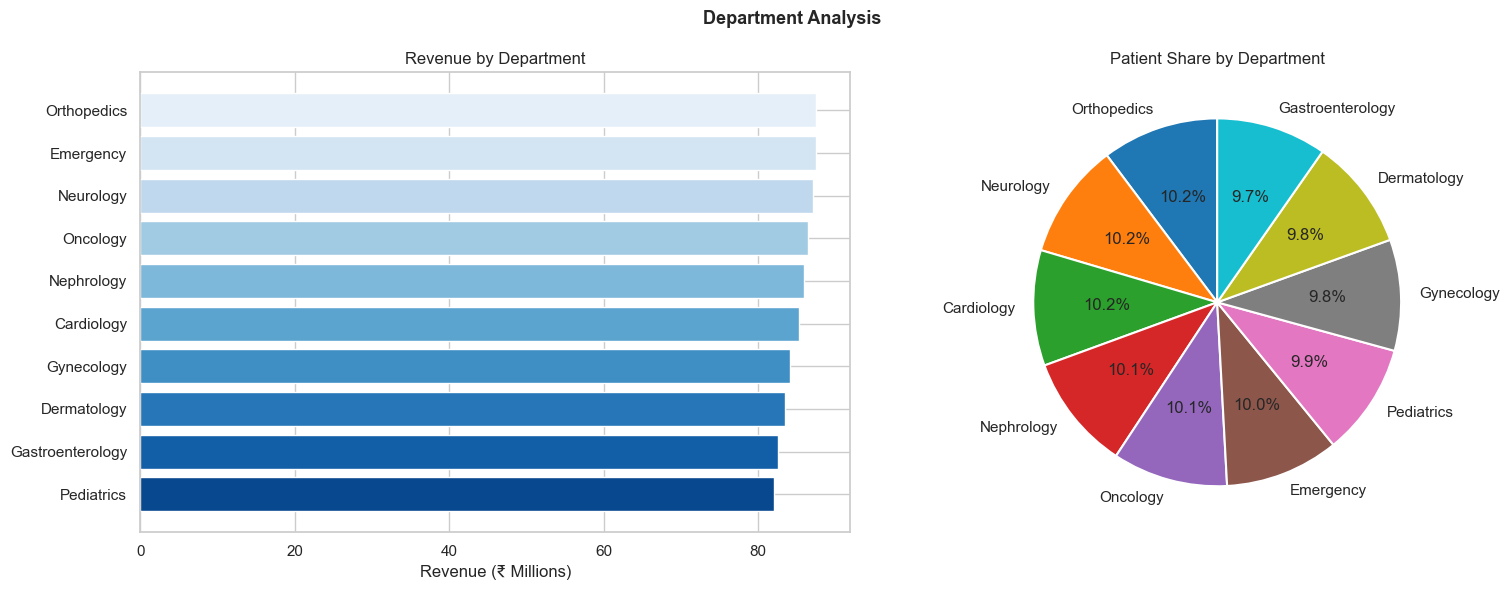

                  Patients  Total_Revenue  Avg_Bill  Avg_Stay
department                                                   
Orthopedics           1025    87514635.44  85380.13     15.49
Emergency             1003     87482433.8  87220.77     15.67
Neurology             1017    87056318.95   85601.1     15.62
Oncology              1013    86412055.96  85303.12     15.48
Nephrology            1015     85924271.0  84654.45     15.23
Cardiology            1016    85318110.76  83974.52     14.82
Gynecology             977    84099021.69  86078.83     15.41
Dermatology            977    83448320.32  85412.82     15.15
Gastroenterology       971    82557175.38  85022.84     15.28
Pediatrics             986     82080805.3  83246.25     15.11


In [12]:
# Department stats
dept_stats = pdf.groupby('department').agg(
    Patients=('patient_id','count'),
    Total_Revenue=('total_bill','sum'),
    Avg_Bill=('total_bill','mean'),
    Avg_Stay=('length_of_stay_days','mean')
).round(2).sort_values('Total_Revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Department Analysis', fontsize=13, fontweight='bold')

dept_rev = dept_stats['Total_Revenue'].sort_values(ascending=True)
axes[0].barh(dept_rev.index, dept_rev.values / 1e6,
              color=sns.color_palette('Blues_r', len(dept_rev)))
axes[0].set_xlabel('Revenue (₹ Millions)')
axes[0].set_title('Revenue by Department')

dept_patients = dept_stats['Patients'].sort_values(ascending=False)
axes[1].pie(dept_patients.values, labels=dept_patients.index,
             autopct='%1.1f%%', colors=sns.color_palette('tab10', len(dept_patients)),
             wedgeprops=dict(edgecolor='white', linewidth=1.5), startangle=90)
axes[1].set_title('Patient Share by Department')

plt.tight_layout()
plt.show()
print(dept_stats.to_string())

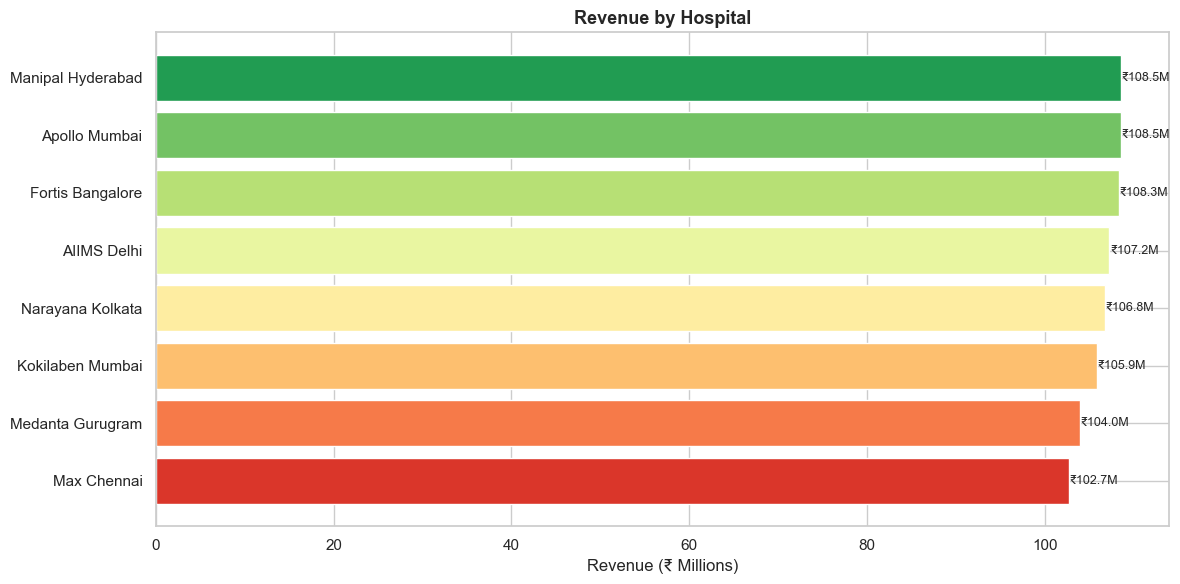

In [13]:
# Hospital revenue
hosp_rev = pdf.groupby('hospital')['total_bill'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(hosp_rev.index, hosp_rev.values / 1e6,
        color=sns.color_palette('RdYlGn', len(hosp_rev)))
ax.set_xlabel('Revenue (₹ Millions)')
ax.set_title('Revenue by Hospital', fontsize=13, fontweight='bold')
for i, v in enumerate(hosp_rev.values):
    ax.text(v/1e6 + 0.1, i, f'₹{v/1e6:.1f}M', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## Section 6 — Monthly Admissions Trend

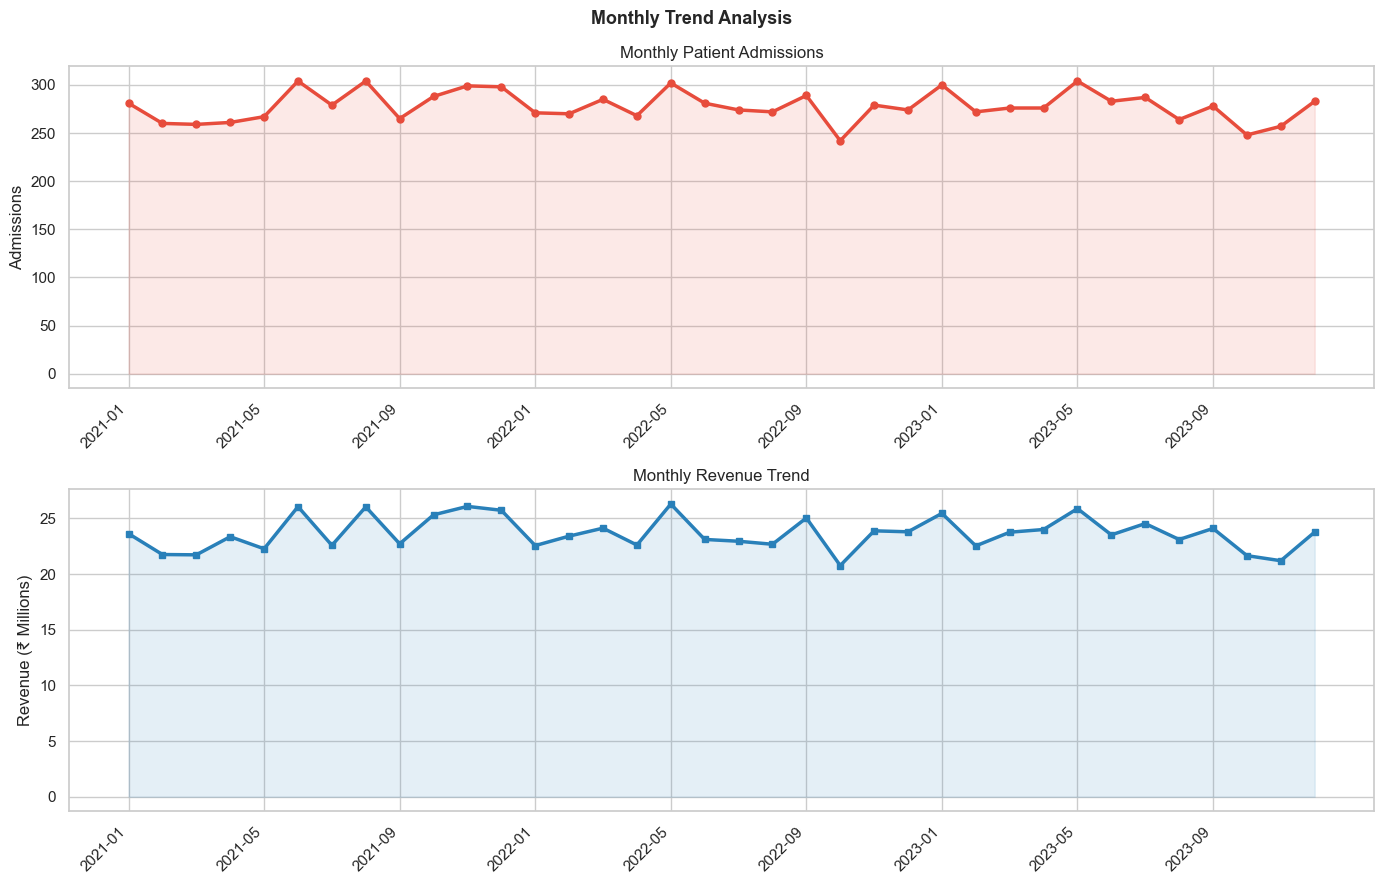

In [14]:
pdf['year_month'] = pdf['admission_date'].dt.to_period('M')
monthly = pdf.groupby('year_month').agg(
    Admissions=('patient_id','count'),
    Revenue=('total_bill','sum')
).reset_index().sort_values('year_month')
monthly['year_month'] = monthly['year_month'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('Monthly Trend Analysis', fontsize=13, fontweight='bold')

# Admissions
axes[0].plot(range(len(monthly)), monthly['Admissions'],
             color='#E74C3C', linewidth=2.5, marker='o', markersize=5)
axes[0].fill_between(range(len(monthly)), monthly['Admissions'],
                      alpha=0.12, color='#E74C3C')
step = max(1, len(monthly) // 8)
axes[0].set_xticks(range(0, len(monthly), step))
axes[0].set_xticklabels(monthly['year_month'].iloc[::step], rotation=45, ha='right')
axes[0].set_ylabel('Admissions')
axes[0].set_title('Monthly Patient Admissions')

# Revenue
axes[1].plot(range(len(monthly)), monthly['Revenue'] / 1e6,
             color='#2980B9', linewidth=2.5, marker='s', markersize=5)
axes[1].fill_between(range(len(monthly)), monthly['Revenue'] / 1e6,
                      alpha=0.12, color='#2980B9')
axes[1].set_xticks(range(0, len(monthly), step))
axes[1].set_xticklabels(monthly['year_month'].iloc[::step], rotation=45, ha='right')
axes[1].set_ylabel('Revenue (₹ Millions)')
axes[1].set_title('Monthly Revenue Trend')

plt.tight_layout()
plt.show()

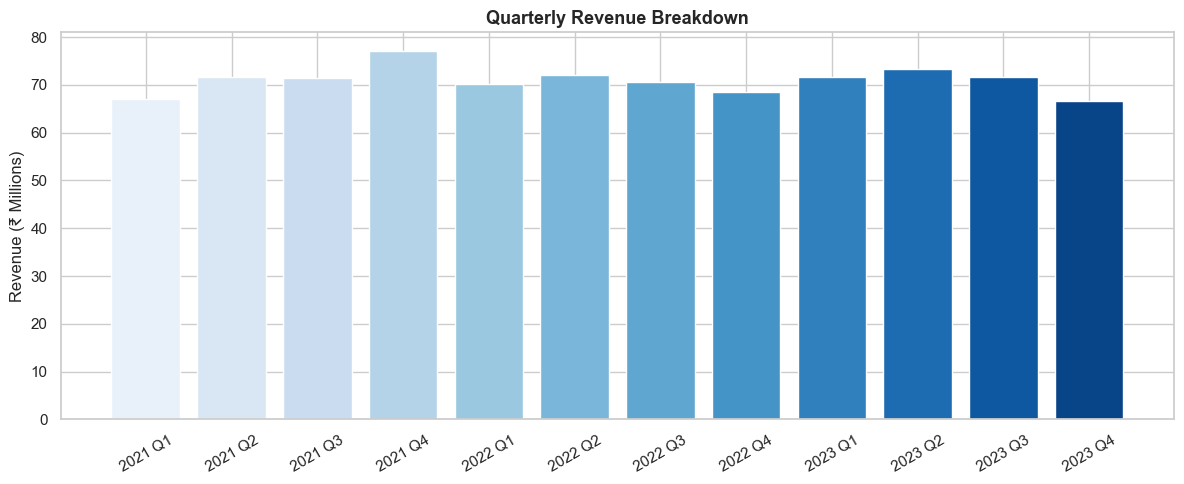

In [15]:
# Quarterly breakdown
qtr = pdf.groupby(['year','quarter'])['total_bill'].sum().reset_index()
qtr['label'] = qtr['year'].astype(str) + ' ' + qtr['quarter']

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(qtr['label'], qtr['total_bill'] / 1e6,
       color=sns.color_palette('Blues', len(qtr)), edgecolor='white')
ax.set_ylabel('Revenue (₹ Millions)')
ax.set_title('Quarterly Revenue Breakdown', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

---
## Section 7 — Payment Mode Analysis

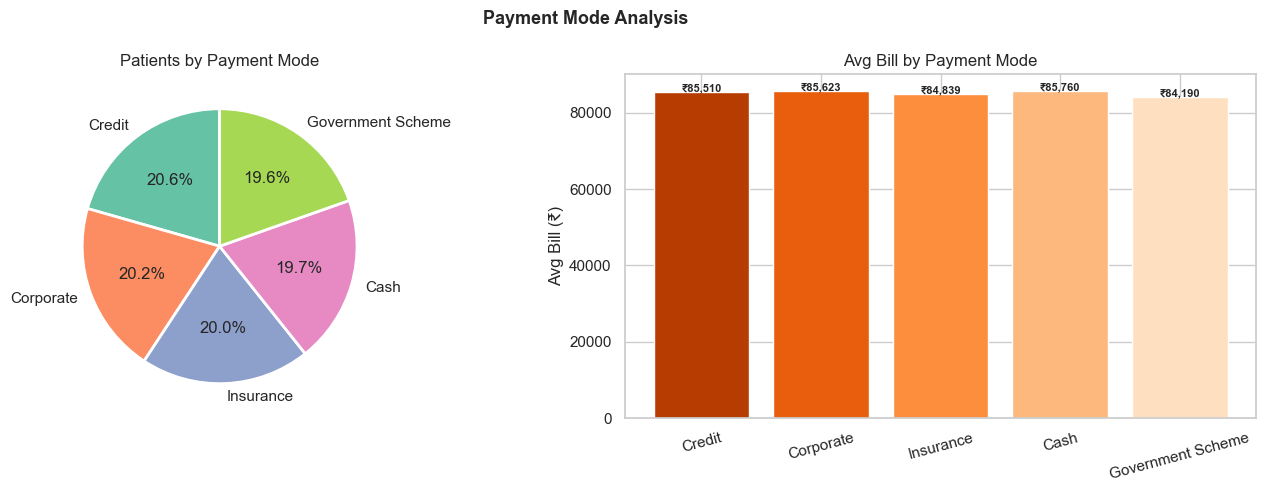

                   Patients  Total_Revenue  Avg_Bill
payment_mode                                        
Credit                 2058   175978901.35  85509.67
Corporate              2016   172616773.82   85623.4
Insurance              1997   169424267.78  84839.39
Cash                   1969   168860681.01  85759.61
Government Scheme      1960   165012524.64  84190.06


In [16]:
pay_stats = pdf.groupby('payment_mode').agg(
    Patients=('patient_id','count'),
    Total_Revenue=('total_bill','sum'),
    Avg_Bill=('total_bill','mean')
).round(2).sort_values('Total_Revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Payment Mode Analysis', fontsize=13, fontweight='bold')

axes[0].pie(pay_stats['Patients'], labels=pay_stats.index,
             autopct='%1.1f%%', colors=sns.color_palette('Set2', len(pay_stats)),
             wedgeprops=dict(edgecolor='white', linewidth=2), startangle=90)
axes[0].set_title('Patients by Payment Mode')

axes[1].bar(pay_stats.index, pay_stats['Avg_Bill'],
             color=sns.color_palette('Oranges_r', len(pay_stats)), edgecolor='white')
axes[1].set_ylabel('Avg Bill (₹)')
axes[1].set_title('Avg Bill by Payment Mode')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(pay_stats['Avg_Bill']):
    axes[1].text(i, v + 200, f'₹{v:,.0f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()
print(pay_stats.to_string())

---
## Section 8 — Patient Demographics Analysis

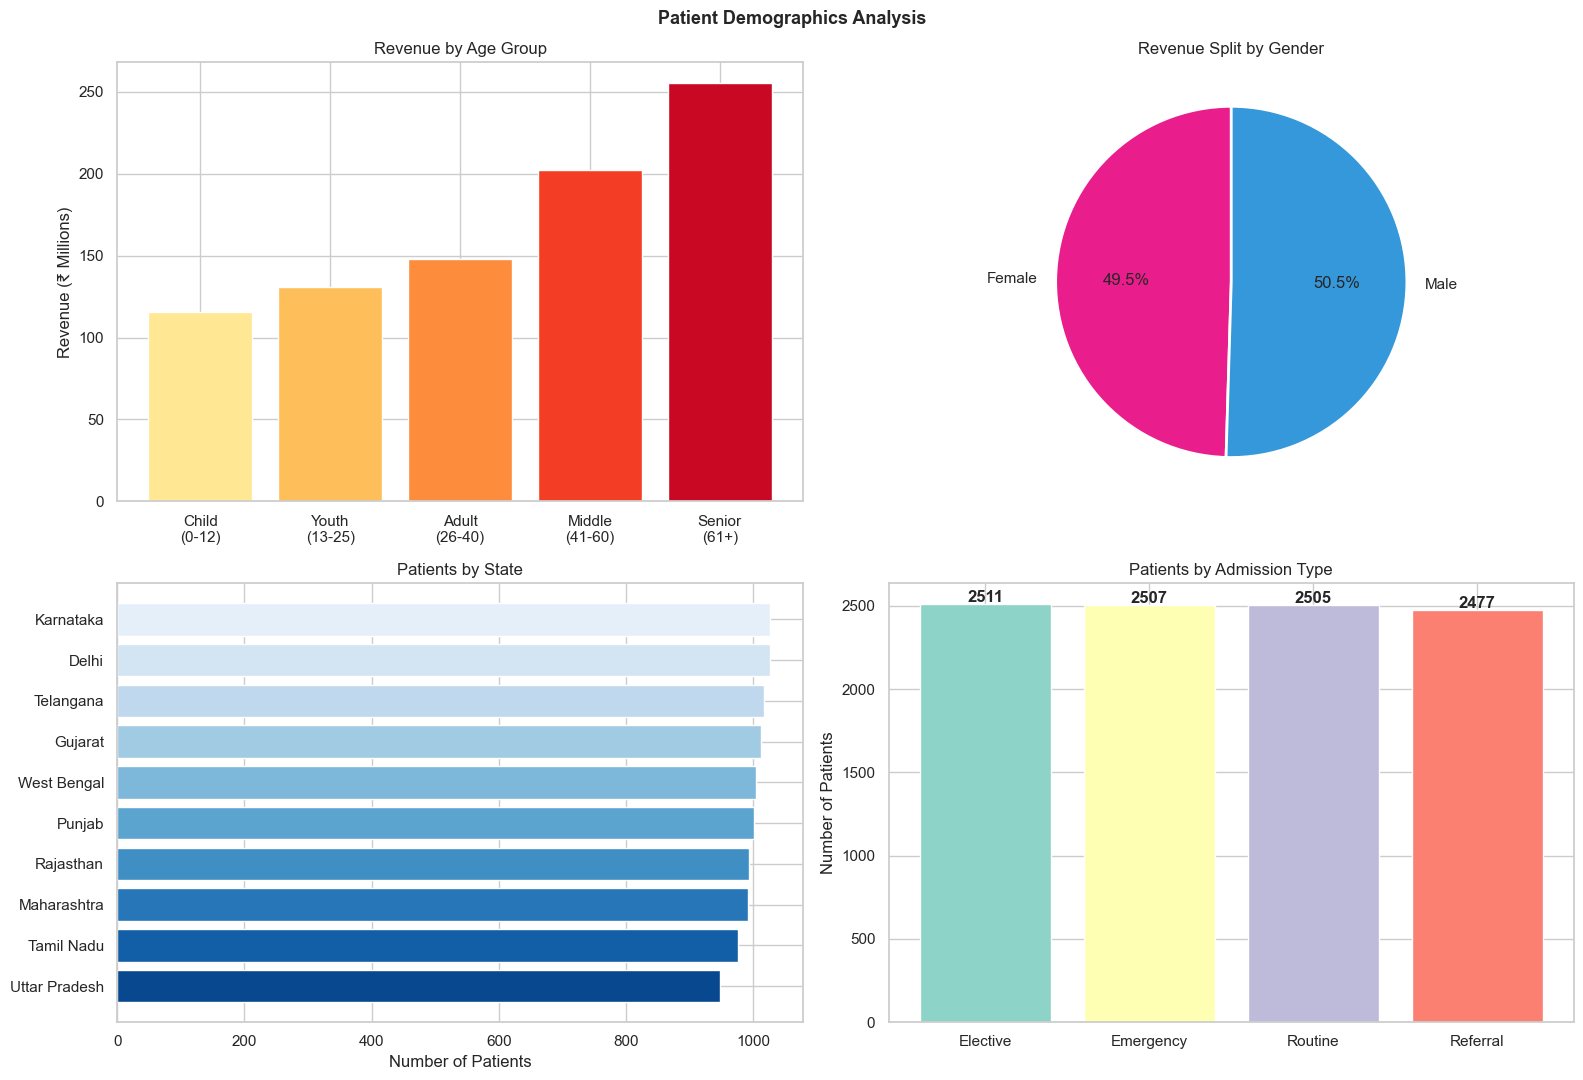

In [17]:
# Age group analysis
pdf['age_group'] = pd.cut(pdf['patient_age'],
    bins=[0, 12, 25, 40, 60, 85],
    labels=['Child\n(0-12)','Youth\n(13-25)','Adult\n(26-40)','Middle\n(41-60)','Senior\n(61+)'])

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Patient Demographics Analysis', fontsize=13, fontweight='bold')

# Age group revenue
age_rev = pdf.groupby('age_group', observed=True)['total_bill'].sum()
axes[0,0].bar(age_rev.index.astype(str), age_rev.values / 1e6,
               color=sns.color_palette('YlOrRd', len(age_rev)), edgecolor='white')
axes[0,0].set_ylabel('Revenue (₹ Millions)')
axes[0,0].set_title('Revenue by Age Group')

# Gender split
gender_rev = pdf.groupby('patient_gender')['total_bill'].sum()
axes[0,1].pie(gender_rev.values, labels=['Female','Male'],
               autopct='%1.1f%%', colors=['#E91E8C','#3498DB'],
               wedgeprops=dict(edgecolor='white', linewidth=2), startangle=90)
axes[0,1].set_title('Revenue Split by Gender')

# State-wise patients
state_patients = pdf.groupby('state')['patient_id'].count().sort_values(ascending=True)
axes[1,0].barh(state_patients.index, state_patients.values,
                color=sns.color_palette('Blues_r', len(state_patients)))
axes[1,0].set_xlabel('Number of Patients')
axes[1,0].set_title('Patients by State')

# Admission type
adm_type = pdf['admission_type'].value_counts()
axes[1,1].bar(adm_type.index, adm_type.values,
               color=sns.color_palette('Set3', len(adm_type)), edgecolor='white')
axes[1,1].set_ylabel('Number of Patients')
axes[1,1].set_title('Patients by Admission Type')
for i, v in enumerate(adm_type.values):
    axes[1,1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## Section 9 — Treatment & Cost Analysis

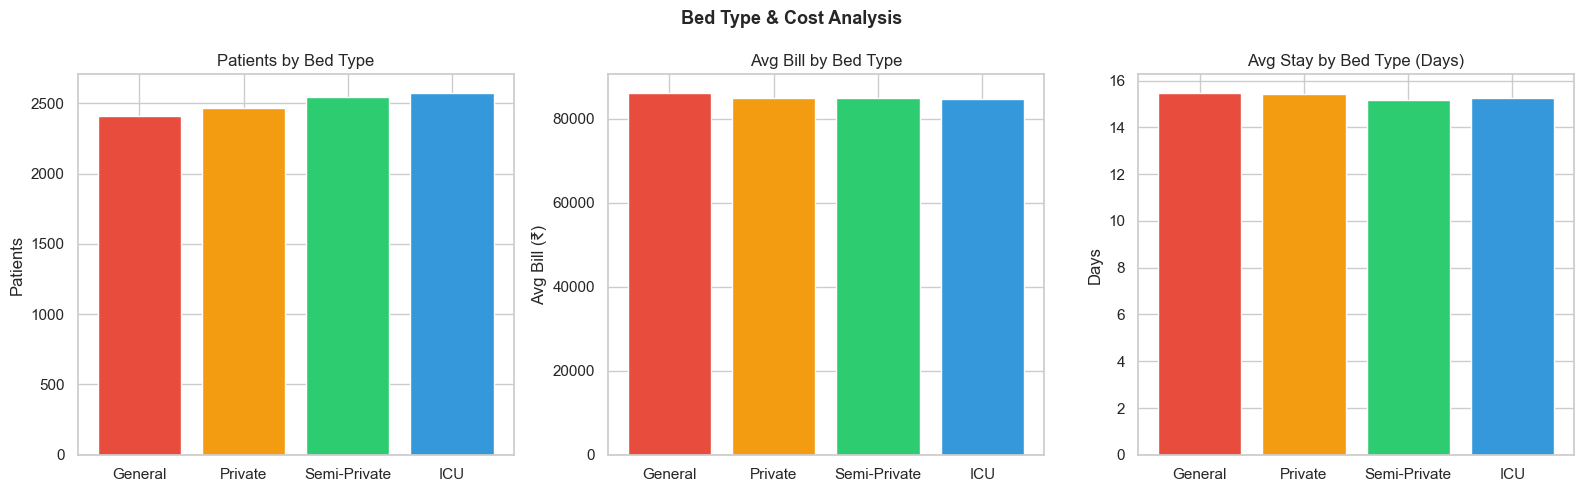

              Patients  Avg_Bill  Avg_Stay
bed_type                                  
General           2411  86258.54     15.49
Private           2467  84907.37     15.41
Semi-Private      2546   84846.8     15.16
ICU               2576  84797.12     15.26


In [18]:
# Bed type analysis
bed_stats = pdf.groupby('bed_type').agg(
    Patients=('patient_id','count'),
    Avg_Bill=('total_bill','mean'),
    Avg_Stay=('length_of_stay_days','mean')
).round(2).sort_values('Avg_Bill', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Bed Type & Cost Analysis', fontsize=13, fontweight='bold')

bed_colors = ['#E74C3C','#F39C12','#2ECC71','#3498DB']
axes[0].bar(bed_stats.index, bed_stats['Patients'],
             color=bed_colors, edgecolor='white')
axes[0].set_title('Patients by Bed Type')
axes[0].set_ylabel('Patients')

axes[1].bar(bed_stats.index, bed_stats['Avg_Bill'],
             color=bed_colors, edgecolor='white')
axes[1].set_title('Avg Bill by Bed Type')
axes[1].set_ylabel('Avg Bill (₹)')

axes[2].bar(bed_stats.index, bed_stats['Avg_Stay'],
             color=bed_colors, edgecolor='white')
axes[2].set_title('Avg Stay by Bed Type (Days)')
axes[2].set_ylabel('Days')

plt.tight_layout()
plt.show()
print(bed_stats.to_string())

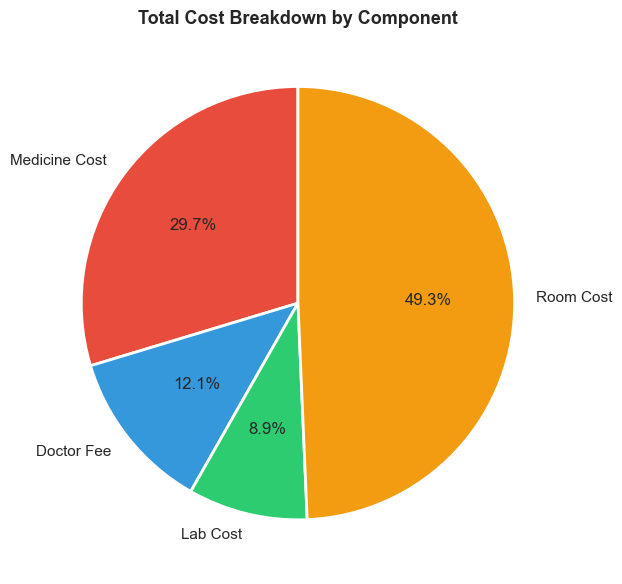

In [19]:
# Cost breakdown
cost_cols = ['medicine_cost','doctor_fee','lab_cost','room_cost']
cost_totals = pdf[cost_cols].sum()

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(cost_totals.values,
       labels=['Medicine Cost','Doctor Fee','Lab Cost','Room Cost'],
       autopct='%1.1f%%',
       colors=['#E74C3C','#3498DB','#2ECC71','#F39C12'],
       wedgeprops=dict(edgecolor='white', linewidth=2), startangle=90)
ax.set_title('Total Cost Breakdown by Component', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 10 — Correlation Analysis

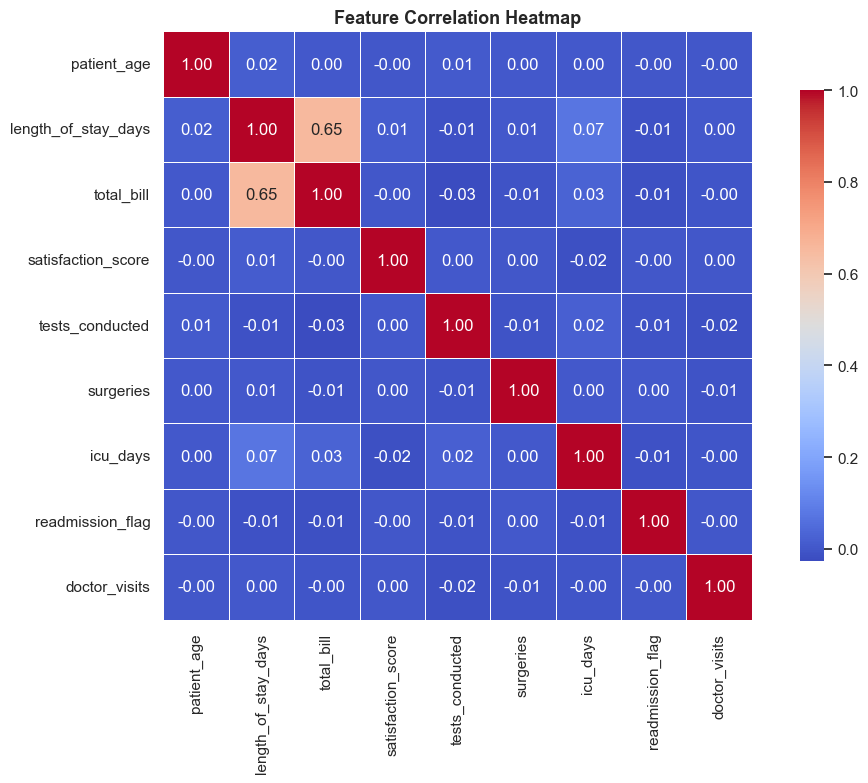

In [20]:
corr_cols = ['patient_age','length_of_stay_days','total_bill',
             'satisfaction_score','tests_conducted','surgeries',
             'icu_days','readmission_flag','doctor_visits']
corr = pdf[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 11 — Dask Scalability Demo

In [21]:
import time

# Dask operation
t1 = time.time()
ddf2 = dd.read_csv('hospital_data.csv', dtype=str)
result_dask = ddf2['department'].value_counts().compute()
t2 = time.time()

# Pandas operation
t3 = time.time()
result_pd = pdf['department'].value_counts()
t4 = time.time()

print('Scalability Demo — value_counts() on 10,000 rows:')
print(f'  Dask (parallel)  : {t2-t1:.4f} sec  | Partitions: {ddf2.npartitions}')
print(f'  Pandas (single)  : {t4-t3:.4f} sec')
print()
print('Why Dask scales:')
print('  For 10M+ rows, Dask splits data into partitions')
print('  and processes them in parallel across CPU cores.')
print('  Pandas would crash due to RAM limits at that scale.')

Scalability Demo — value_counts() on 10,000 rows:
  Dask (parallel)  : 0.3317 sec  | Partitions: 1
  Pandas (single)  : 0.0018 sec

Why Dask scales:
  For 10M+ rows, Dask splits data into partitions
  and processes them in parallel across CPU cores.
  Pandas would crash due to RAM limits at that scale.


---
## Section 12 — Final Insights Summary

In [22]:
top_dept  = dept_stats['Total_Revenue'].idxmax()
top_hosp  = pdf.groupby('hospital')['total_bill'].sum().idxmax()
top_pay   = pay_stats['Total_Revenue'].idxmax()
top_state = pdf.groupby('state')['patient_id'].count().idxmax()
top_age   = pdf.groupby('age_group', observed=True)['patient_id'].count().idxmax()
top_adm   = pdf['admission_type'].value_counts().idxmax()

print('=' * 60)
print('    🏥 FINAL INSIGHTS — HOSPITAL BIG DATA ANALYSIS')
print('=' * 60)
print(f'  Total Patients Processed    : {total_patients:,}')
print(f'  Total Hospital Revenue      : ₹{total_revenue:,.0f}')
print(f'  Avg Bill per Patient        : ₹{avg_bill:,.2f}')
print(f'  Top Revenue Department      : {top_dept}')
print(f'  Top Revenue Hospital        : {top_hosp}')
print(f'  Most Used Payment Mode      : {top_pay}')
print(f'  Most Patients from State    : {top_state}')
print(f'  Largest Age Group           : {top_age}')
print(f'  Most Common Admission Type  : {top_adm}')
print(f'  Avg Length of Stay          : {avg_stay:.1f} days')
print(f'  Avg Satisfaction Score      : {avg_satisfaction:.2f} / 5.0')
print(f'  Readmission Rate            : {readmit_rate:.2f}%')
print(f'  Total ICU Patients          : {icu_patients:,}')
print()
print('  Dask Big Data Advantage:')
print('  • 10,000 records processed in parallel partitions')
print('  • Same code scales to 10 million rows on a cluster')
print('  • Lazy evaluation — compute() triggers execution')
print('=' * 60)
print('\n✅  Task 1 Complete!')

    🏥 FINAL INSIGHTS — HOSPITAL BIG DATA ANALYSIS
  Total Patients Processed    : 10,000
  Total Hospital Revenue      : ₹851,893,149
  Avg Bill per Patient        : ₹85,189.31
  Top Revenue Department      : Orthopedics
  Top Revenue Hospital        : Manipal Hyderabad
  Most Used Payment Mode      : Credit
  Most Patients from State    : Delhi
  Largest Age Group           : Senior
(61+)
  Most Common Admission Type  : Elective
  Avg Length of Stay          : 15.3 days
  Avg Satisfaction Score      : 3.50 / 5.0
  Readmission Rate            : 25.60%
  Total ICU Patients          : 2,576

  Dask Big Data Advantage:
  • 10,000 records processed in parallel partitions
  • Same code scales to 10 million rows on a cluster
  • Lazy evaluation — compute() triggers execution

✅  Task 1 Complete!


---
*CODTECH IT Solutions Pvt. Ltd. — Data Analytics Internship — Task 1*